In [2]:
import re
from pathlib import Path

import rootutils

rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap
from omegaconf import OmegaConf
from PIL import Image

from hydra.utils import instantiate

from src.inference import load_model_and_transform
from src.viaABC.systems import Spatial2D

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [4]:
# -----------------------------
# 1. Configuration
# -----------------------------
PROJECT_ROOT = Path(rootutils.find_root(Path.cwd(), indicator=".project-root"))

# HPC run path configuration.
RUN_ROOT = Path("/insomnia001/depts/iicd/users/kz2537/viaABC/run")
# Inference output / Slurm job to inspect
OUTPUT_ID = "9680710"
# Default training run (set to the specific run corresponding to OUTPUT_ID when known).
RUN_FOLDER_PATH = RUN_ROOT / "train" / "spatial2D" / "2026-05-07_14-19-08_bs10_acc2_nw2"
CHECKPOINT_SUBSTR = "last"
TRAIN_CFG_PATH = RUN_FOLDER_PATH / ".hydra" / "config.yaml"
TRAIN_CFG = OmegaConf.load(TRAIN_CFG_PATH)
BASE_SYSTEM_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "system" / "spatial2D.yaml")
TRAIN_MODEL_NUM_FRAMES = int(TRAIN_CFG.model.net.get("num_frames", 1))


def add_temporal_observation_paths(observation_samples):
    samples = OmegaConf.to_container(observation_samples, resolve=True)
    if not TRAIN_CFG.data.datamodule.dataset.get("temporal", False) or TRAIN_MODEL_NUM_FRAMES <= 1:
        return OmegaConf.create(samples)

    candidate_roots = [
        Path(TRAIN_CFG.data.datamodule.data_dir),
        PROJECT_ROOT / "data" / "spatial2D",
    ]
    for sample_name, sample_cfg in samples.items():
        if sample_cfg.get("temporal_observation") is not None:
            continue
        temporal_name = f"{sample_name}_t{TRAIN_MODEL_NUM_FRAMES}_true_theta.npy"
        for root in candidate_roots:
            temporal_path = root / "observation_paths" / temporal_name
            if temporal_path.exists():
                sample_cfg["temporal_observation"] = str(temporal_path)
                break
    return OmegaConf.create(samples)


TRAIN_SYSTEM_CFG = OmegaConf.create(OmegaConf.to_container(BASE_SYSTEM_CFG.system, resolve=False))
TRAIN_OBSERVATION_SAMPLES = add_temporal_observation_paths(TRAIN_CFG.data.observation_samples)
TRAIN_SYSTEM_CFG.observation_samples = TRAIN_OBSERVATION_SAMPLES
TRAIN_SYSTEM_CFG.sample_id = TRAIN_CFG.data.get("observation_sample", "sample_1")
TRAIN_SYSTEM_CFG.use_time_series = TRAIN_CFG.data.datamodule.dataset.get("temporal", TRAIN_SYSTEM_CFG.get("use_time_series", True))
SAMPLE_ID = TRAIN_CFG.data.get("observation_sample", "sample_1")

# Keep the inference tiny but still numerically valid for debugging.
ABC_DEBUG_CFG = {
    "num_particles": 10,
    "k": 10,
    "q_threshold": 0.90,
    "max_generations": 1,
    "num_workers": 10,
    "simulation_batch_size": 1,
    "max_pending_simulations": 1,
}

if ABC_DEBUG_CFG["num_particles"] < 2:
    raise ValueError("Please keep num_particles >= 2 for debugging.")

BASE_INFERENCE_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "inference.yaml")
SPATIAL2D_INFERENCE_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "inference" / "spatial2D.yaml")
DATA_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "data" / "spatial2D.yaml")
INFERENCE_CFG = OmegaConf.merge(BASE_INFERENCE_CFG, SPATIAL2D_INFERENCE_CFG)
INFERENCE_CFG.data = DATA_CFG

PARAM_NAMES = ["alpha", "beta", "gamma"]
STATE_CMAP = ListedColormap([
    "#d73027",
    "#fee08b",
    "#4575b4",
    "#2b1744",
    "#1a9850",
    "#d9d9d9",
])

print("RUN_FOLDER_PATH:", RUN_FOLDER_PATH)
print("TRAIN_CFG_PATH:", TRAIN_CFG_PATH)
print("SAMPLE_ID:", SAMPLE_ID)
print("ABC_DEBUG_CFG:", ABC_DEBUG_CFG)


RUN_FOLDER_PATH: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-05-07_14-19-08_bs10_acc2_nw2
TRAIN_CFG_PATH: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-05-07_14-19-08_bs10_acc2_nw2/.hydra/config.yaml
SAMPLE_ID: sample_1
ABC_DEBUG_CFG: {'num_particles': 10, 'k': 10, 'q_threshold': 0.9, 'max_generations': 1, 'num_workers': 10, 'simulation_batch_size': 1, 'max_pending_simulations': 1}


In [5]:
# -----------------------------
# 2. Minimal helper logic
# -----------------------------
sample_cfg = OmegaConf.to_container(TRAIN_OBSERVATION_SAMPLES[SAMPLE_ID], resolve=True)


def resolve_sample_path(path_value):
    path = Path(str(path_value).replace("${paths.data_dir}", str(TRAIN_CFG.paths.data_dir)))
    return path if path.is_absolute() else PROJECT_ROOT / path


txt_path = resolve_sample_path(sample_cfg["txt"])

image_candidates = []
if sample_cfg.get("image") is not None:
    image_candidates.append(resolve_sample_path(sample_cfg["image"]))

match = re.search(r"(\d+)$", SAMPLE_ID)
if match is not None:
    idx = match.group(1)
    image_candidates.extend([
        PROJECT_ROOT / "data" / "spatial2D" / f"img{idx}.jpg",
        PROJECT_ROOT / "data" / "spatial2D" / f"image{idx}_processed.jpg",
        PROJECT_ROOT / "data" / "spatial2D" / f"image{idx}.jpg",
    ])

raw_image_path = next((path for path in image_candidates if path.exists()), None)


def final_label_frame(grid):
    grid = np.asarray(grid)
    return grid[-1] if grid.ndim == 3 else grid


def draw_grid(ax, grid, title):
    grid = final_label_frame(grid)
    ax.imshow(grid, cmap=STATE_CMAP, vmin=0, vmax=5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


def weighted_quantile(values, quantile, weights):
    values = np.asarray(values)
    weights = np.asarray(weights)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative = cumulative / weights.sum()
    return np.interp(quantile, cumulative, values)

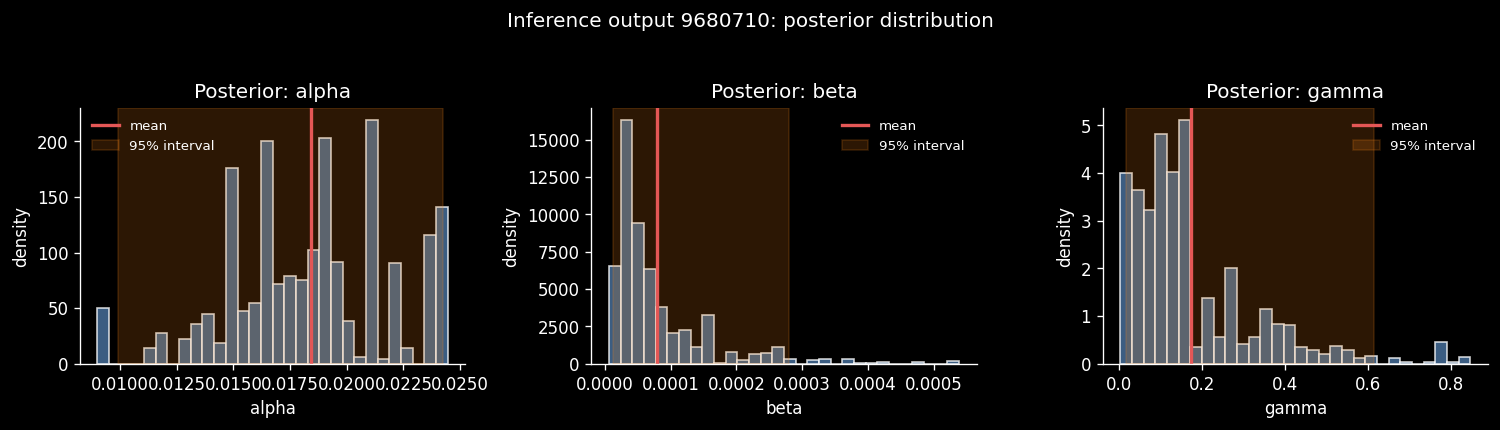

posterior npy: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-05-07_14-19-08_bs10_acc2_nw2/inference_output/2026-05-21_01-13-03_4c02dda1/abc_generations.npy
generation: 3
particles shape: (100, 3)
epsilon: 0.027712896

Posterior summary
   alpha: mean=0.0184105, median=0.018739, 95%=[0.00990856, 0.02424]
    beta: mean=7.9036e-05, median=4.98323e-05, 95%=[1.20825e-05, 0.000280574]
   gamma: mean=0.173507, median=0.119288, 95%=[0.0151537, 0.613964]


In [16]:
# -----------------------------
# 3. Plot posterior histograms from inference output 9680710
# -----------------------------
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_ID = "9680710"
RUN_ROOT = Path("/insomnia001/depts/iicd/users/kz2537/viaABC/run")

# Slurm job 9680710 wrote this path in run/slurm/viaabc-spatial2d-infer-9680710.out.
POSTERIOR_NPY_PATH = Path(
    "/insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/"
    "2026-05-07_14-19-08_bs10_acc2_nw2/inference_output/"
    "2026-05-21_01-13-03_4c02dda1/abc_generations.npy"
)


def find_inference_npy(output_id, run_root):
    search_roots = [run_root]
    seen = set()
    matches = []

    for root in search_roots:
        root = Path(root).expanduser().resolve()
        if root in seen or not root.exists():
            continue
        seen.add(root)

        for path in root.rglob("abc_generations.npy"):
            path_text = str(path)
            sibling_text = "\n".join(str(candidate) for candidate in path.parent.parent.glob(f"*{output_id}*"))
            log_text = path.parent.joinpath("inference.log").read_text(errors="ignore") if path.parent.joinpath("inference.log").exists() else ""
            if output_id in path_text or output_id in sibling_text or output_id in log_text:
                matches.append(path)

    if not matches:
        return None
    return sorted(matches, key=lambda p: (p.name != "abc_generations.npy", len(str(p))))[0]


def load_generations(path):
    path = Path(path).expanduser()
    loaded = np.load(path, allow_pickle=True)

    if isinstance(loaded, np.lib.npyio.NpzFile):
        if "generations" in loaded:
            loaded = loaded["generations"]
        else:
            loaded = loaded[loaded.files[0]]

    if isinstance(loaded, np.ndarray) and loaded.shape == ():
        loaded = loaded.item()
    elif isinstance(loaded, np.ndarray) and loaded.dtype == object:
        loaded = loaded.tolist()

    if isinstance(loaded, dict) and "generations" in loaded:
        loaded = loaded["generations"]

    return loaded


def weighted_quantile_1d(values, quantile, weights):
    values = np.asarray(values)
    weights = np.asarray(weights)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative = cumulative / weights.sum()
    return np.interp(quantile, cumulative, values)


posterior_path = Path(POSTERIOR_NPY_PATH) if POSTERIOR_NPY_PATH is not None else find_inference_npy(OUTPUT_ID, RUN_ROOT)
if posterior_path is None:
    raise FileNotFoundError(
        f"Could not find inference npy for output {OUTPUT_ID}. "
        "Set POSTERIOR_NPY_PATH to the abc_generations.npy file and rerun this cell."
    )

generations = load_generations(posterior_path)
last_generation = generations[-1] if isinstance(generations, (list, tuple)) else generations

particles = np.asarray(last_generation["particles"], dtype=float)
weights = np.asarray(last_generation.get("weights", np.ones(len(particles))), dtype=float)
weights = weights / weights.sum()

if particles.ndim == 1:
    particles = particles[:, None]

default_param_names = ["alpha", "beta", "gamma"]
param_names = default_param_names[: particles.shape[1]]
if len(param_names) < particles.shape[1]:
    param_names = param_names + [f"theta_{i}" for i in range(len(param_names), particles.shape[1])]

fig, axes = plt.subplots(1, particles.shape[1], figsize=(4.2 * particles.shape[1], 3.4), squeeze=False)
axes = axes.ravel()

summary_rows = []
for i, (ax, name) in enumerate(zip(axes, param_names)):
    values = particles[:, i]
    mean = np.average(values, weights=weights)
    q025 = weighted_quantile_1d(values, 0.025, weights)
    q500 = weighted_quantile_1d(values, 0.500, weights)
    q975 = weighted_quantile_1d(values, 0.975, weights)
    summary_rows.append((name, mean, q500, q025, q975))

    ax.hist(values, bins=30, weights=weights, density=True, color="#4C78A8", alpha=0.78, edgecolor="white")
    ax.axvline(mean, color="#E45756", lw=2, label="mean")
    ax.axvspan(q025, q975, color="#F58518", alpha=0.18, label="95% interval")
    ax.set_title(f"Posterior: {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(f"Inference output {OUTPUT_ID}: posterior distribution", y=1.04)
fig.tight_layout()
plt.show()

print("posterior npy:", posterior_path)
print("generation:", last_generation.get("t", len(generations) - 1 if isinstance(generations, (list, tuple)) else "unknown"))
print("particles shape:", particles.shape)
print("epsilon:", last_generation.get("epsilon", None))
print("\nPosterior summary")
for name, mean, median, q025, q975 in summary_rows:
    print(f"{name:>8s}: mean={mean:.6g}, median={median:.6g}, 95%=[{q025:.6g}, {q975:.6g}]")


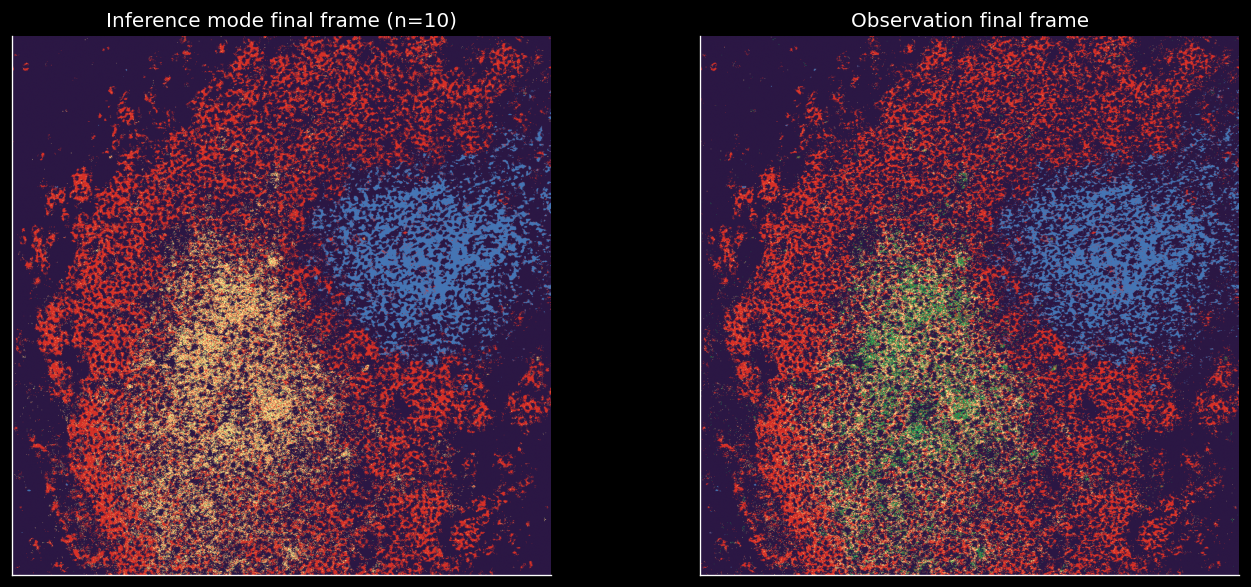

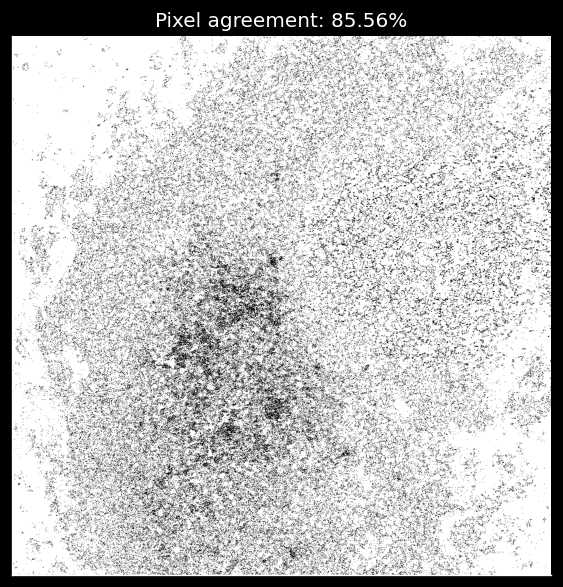

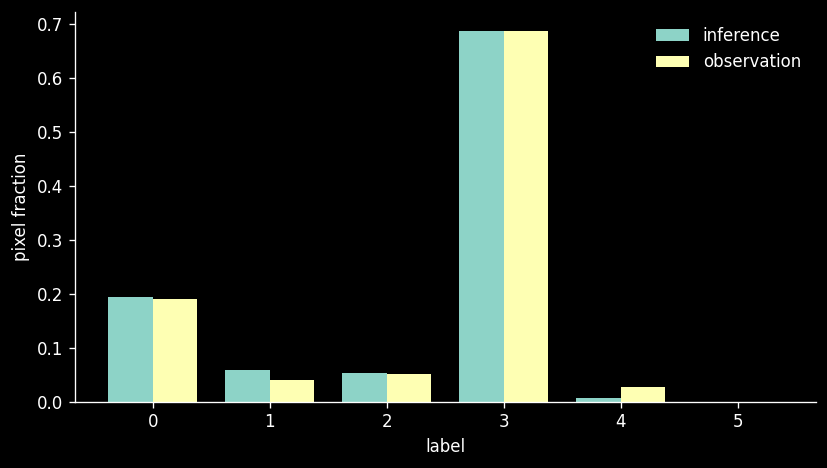

posterior mean theta: {'alpha': np.float64(0.018410482579260153), 'beta': np.float64(7.90360339268448e-05), 'gamma': np.float64(0.17350708516566923)}
simulation statuses: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
simulated final frames shape: (10, 1200, 1200)
inference mode frame shape: (1200, 1200)
observation final frame shape: (1200, 1200)
pixel agreement: 0.8556347222222223


In [21]:
# -----------------------------
# 4. Simulate posterior-mean particles and compare final-frame mode with observation
# -----------------------------
from scipy import stats

N_POSTERIOR_MEAN_SIMULATIONS = 10
SAMPLE_INDEX = 0

if "particles" not in globals() or "weights" not in globals():
    raise NameError("Please run the posterior histogram cell first so `particles` and `weights` exist.")

if "trained_system" in globals():
    spatial2d_system = trained_system
elif "system" in globals():
    spatial2d_system = system
else:
    spatial2d_system = instantiate(TRAIN_SYSTEM_CFG)
posterior_mean_theta = np.average(particles, weights=weights, axis=0)
target_final_time = np.array([float(spatial2d_system.tmax)])

simulated_final_frames = []
simulation_statuses = []
for _ in range(N_POSTERIOR_MEAN_SIMULATIONS):
    if hasattr(spatial2d_system, "_simulate_with_core"):
        simulated_grid, status = spatial2d_system._simulate_with_core(
            SAMPLE_INDEX,
            posterior_mean_theta,
            target_final_time,
        )
    else:
        simulated_grid, status = spatial2d_system.simulate(
            posterior_mean_theta,
            time_space=target_final_time,
        )

    simulated_final_frames.append(final_label_frame(simulated_grid))
    simulation_statuses.append(status)

simulated_final_frames = np.stack(simulated_final_frames, axis=0)
inference_mode_frame = stats.mode(simulated_final_frames, axis=0, keepdims=False).mode.astype(np.uint8)

observed_source = getattr(spatial2d_system, "_observation_grids", spatial2d_system.observational_data)
observed_source = np.asarray(observed_source)
if observed_source.ndim == 4:
    observation_final_frame = final_label_frame(observed_source[SAMPLE_INDEX])
else:
    observation_final_frame = final_label_frame(observed_source)

agreement_mask = inference_mode_frame == observation_final_frame

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_grid(axes[0], inference_mode_frame, f"Inference mode final frame (n={N_POSTERIOR_MEAN_SIMULATIONS})")
draw_grid(axes[1], observation_final_frame, "Observation final frame")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(agreement_mask, cmap="gray", vmin=0, vmax=1)
ax.set_title(f"Pixel agreement: {agreement_mask.mean():.2%}")
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()

labels = np.arange(max(6, int(max(inference_mode_frame.max(), observation_final_frame.max())) + 1))
inference_label_hist = np.bincount(inference_mode_frame.reshape(-1), minlength=len(labels))
observation_label_hist = np.bincount(observation_final_frame.reshape(-1), minlength=len(labels))

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.38
ax.bar(labels - width / 2, inference_label_hist / inference_label_hist.sum(), width=width, label="inference")
ax.bar(labels + width / 2, observation_label_hist / observation_label_hist.sum(), width=width, label="observation")
ax.set_xlabel("label")
ax.set_ylabel("pixel fraction")
ax.set_xticks(labels)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("posterior mean theta:", dict(zip(param_names, posterior_mean_theta)))
print("simulation statuses:", simulation_statuses)
print("simulated final frames shape:", simulated_final_frames.shape)
print("inference mode frame shape:", inference_mode_frame.shape)
print("observation final frame shape:", observation_final_frame.shape)
print("pixel agreement:", agreement_mask.mean())


### label-5 / state_H leakage diagnostic

sample_1 initial txt: shape=(1200, 1200), label5 pixels=0
sample_1 initial txt: onehot channel-5 pixels=0, decoded label5 pixels=0
sample_1 initial txt: label5 decoded as 0 pixels=0
sample_1 initial txt: roundtrip exact=True
sample_1 final image_to_grid: shape=(1200, 1200), label5 pixels=0
sample_1 final image_to_grid: onehot channel-5 pixels=0, decoded label5 pixels=0
sample_1 final image_to_grid: label5 decoded as 0 pixels=0
sample_1 final image_to_grid: roundtrip exact=True


INFO:src.viaABC.systems:Spatial2D sample sample_1: initial txt=/insomnia001/home/kz2537/viaABC/data/spatial2D/initial_grid1_cpp.txt, observed raw image=/insomnia001/home/kz2537/viaABC/data/spatial2D/img1.jpg, observed final grid source=raw image -> grid, raw image shape=(1200, 1200, 3), grid shape=(1200, 1200)
INFO:src.viaABC.viaABC:Initializing viaABC class
The class can be initialized without a model, but it will not
be able to run the algorithm.
INFO:src.viaABC.viaABC:viaABC class initialized with the following parameters:
INFO:src.viaABC.viaABC:num_parameters: 3
INFO:src.viaABC.viaABC:Mu: [0. 0. 0.]
INFO:src.viaABC.viaABC:Sigma: [1. 1. 1.]
INFO:src.viaABC.viaABC:t0: 0
INFO:src.viaABC.viaABC:tmax: 24
INFO:src.viaABC.viaABC:time_space: None
INFO:src.viaABC.viaABC:pooling_method: no_cls
INFO:src.viaABC.viaABC:metric: pairwise_cosine


sample_1 simulate theta=[0.5, 0.5, 0.5], status=0
sample_1 simulated theta=[0.5, 0.5, 0.5]: shape=(1200, 1200), label5 pixels=94707
sample_1 simulated theta=[0.5, 0.5, 0.5]: onehot channel-5 pixels=94707, decoded label5 pixels=94707
sample_1 simulated theta=[0.5, 0.5, 0.5]: label5 decoded as 0 pixels=0
sample_1 simulated theta=[0.5, 0.5, 0.5]: roundtrip exact=True
sample_1 final raw high-grey candidate pixels=592
sample_1 final high-grey allocated to label 0 pixels=592
sample_1 final unclassified raw pixels=67410


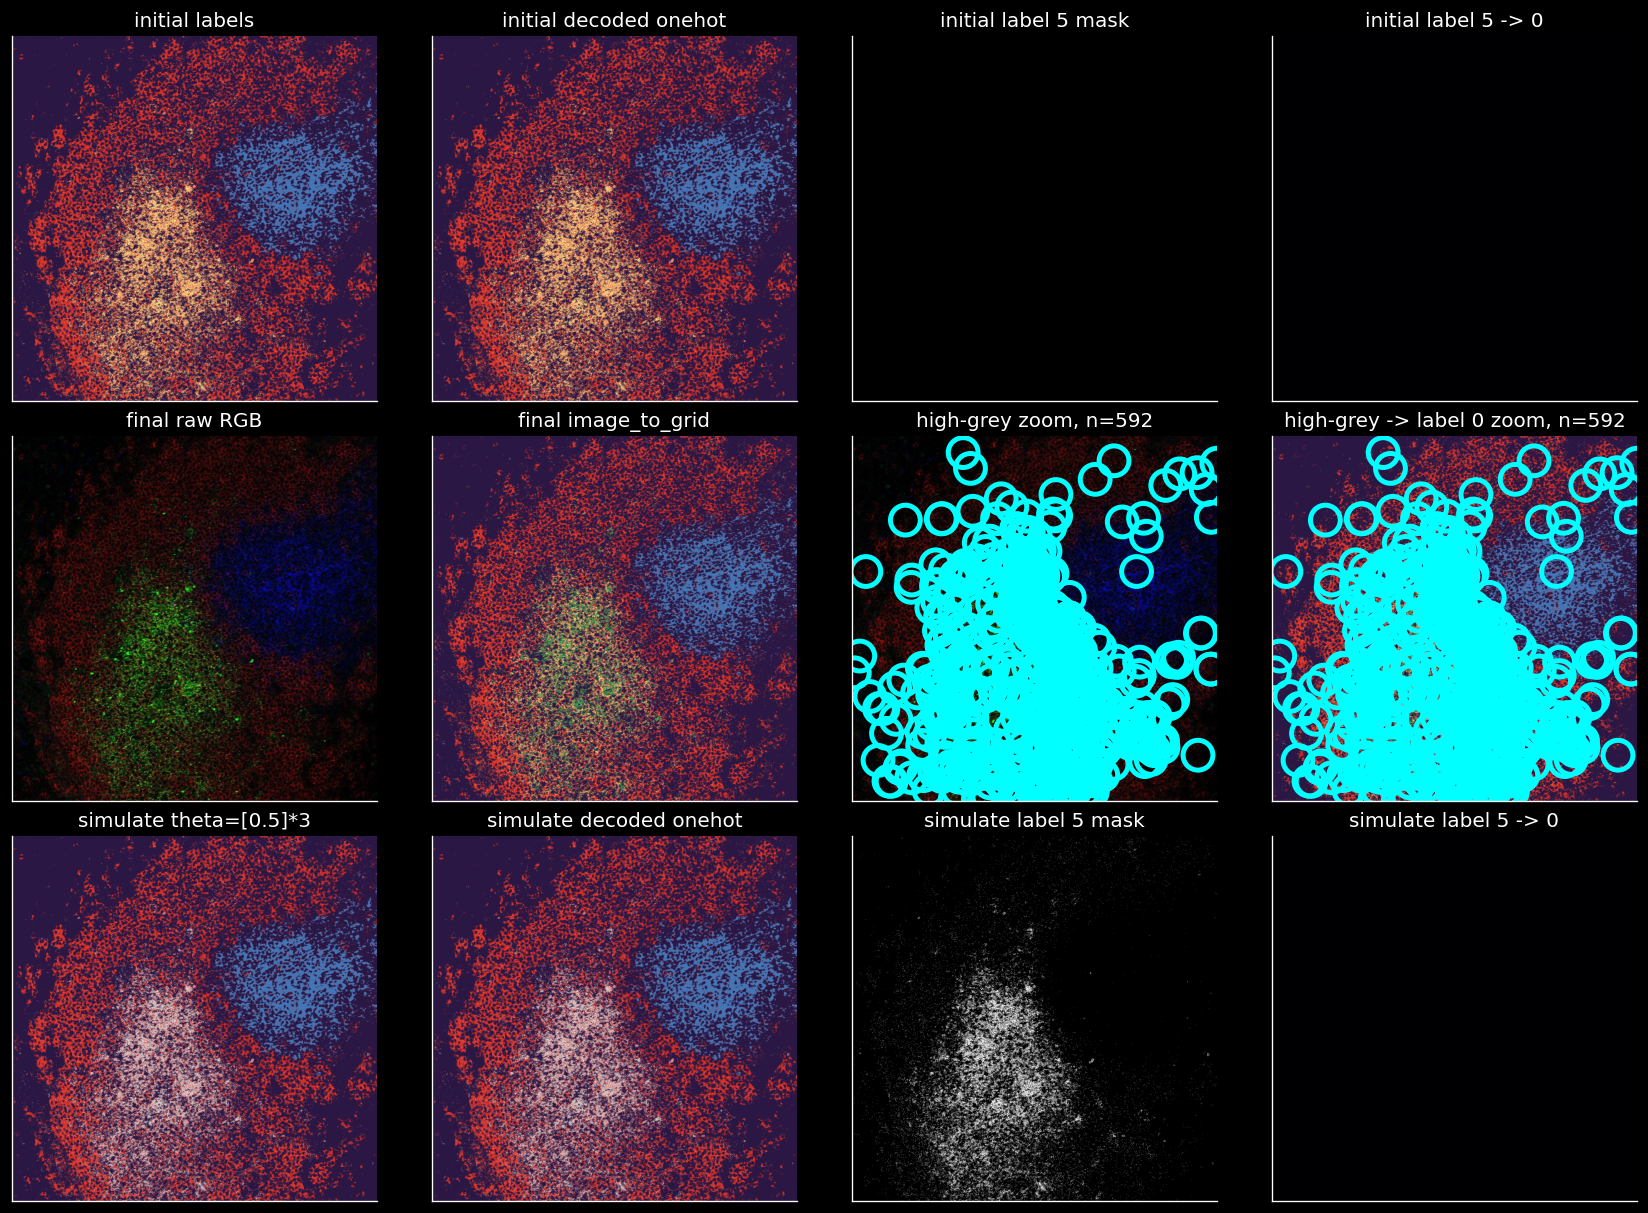

In [10]:
# -----------------------------
# 5. Sample 1 Spatial2D label-5 / state_H leakage diagnostic
# -----------------------------
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from omegaconf import OmegaConf
from PIL import Image

from src.viaABC.systems import Spatial2D

PROJECT_ROOT = Path(rootutils.find_root(Path.cwd(), indicator=".project-root"))
SAMPLE_ID_FOR_LABEL_CHECK = "sample_1"
if "TRAIN_OBSERVATION_SAMPLES" in globals() and "resolve_sample_path" in globals():
    SAMPLE_CFG = OmegaConf.to_container(TRAIN_OBSERVATION_SAMPLES[SAMPLE_ID_FOR_LABEL_CHECK], resolve=True)
    path_resolver = resolve_sample_path
else:
    DATA_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "data" / "spatial2D.yaml")
    SAMPLE_CFG = OmegaConf.to_container(
        DATA_CFG.observation_samples[SAMPLE_ID_FOR_LABEL_CHECK], resolve=False
    )
    path_resolver = lambda path_value: Path(
        str(path_value).replace("${paths.data_dir}", str(PROJECT_ROOT / "data"))
    )

state_cmap = globals().get(
    "STATE_CMAP",
    ListedColormap(["#cc3d3d", "#d8c84b", "#3358cc", "#111111", "#42a85b", "#b8b8b8"]),
)
def onehot_roundtrip_report(grid, name):
    grid = np.asarray(grid)
    onehot = Spatial2D.labels2map(None, grid)
    decoded = onehot.argmax(axis=0).astype(grid.dtype)
    label5_mask = grid == 5
    label5_to_zero = label5_mask & (decoded == 0)
    print(f"{name}: shape={grid.shape}, label5 pixels={int(label5_mask.sum())}")
    print(f"{name}: onehot channel-5 pixels={int(onehot[5].sum())}, decoded label5 pixels={int((decoded == 5).sum())}")
    print(f"{name}: label5 decoded as 0 pixels={int(label5_to_zero.sum())}")
    print(f"{name}: roundtrip exact={bool(np.array_equal(decoded, grid))}")
    return onehot, decoded, label5_mask, label5_to_zero




def scatter_mask(ax, mask, color="cyan", size=120, linewidth=2.2):
    ys, xs = np.where(mask)
    ax.scatter(xs, ys, s=size, facecolors="none", edgecolors=color, linewidths=linewidth)

def image_to_grid_masks(img):
    red_threshold = 40
    green_threshold = 40
    blue_threshold = 50
    yellow = (img[:, :, 0] > red_threshold) & (img[:, :, 1] > green_threshold) & (img[:, :, 2] < blue_threshold)
    no_color = (img[:, :, 0] < red_threshold) & (img[:, :, 1] < green_threshold) & (img[:, :, 2] < blue_threshold)
    red = (img[:, :, 0] > red_threshold) & (img[:, :, 1] < green_threshold) & (img[:, :, 2] < blue_threshold)
    green = (img[:, :, 0] < red_threshold) & (img[:, :, 1] > green_threshold) & (img[:, :, 2] < blue_threshold)
    blue = (img[:, :, 0] < red_threshold) & (img[:, :, 1] < green_threshold) & (img[:, :, 2] > blue_threshold)
    classified = yellow | no_color | red | green | blue
    high_grey = (~classified) & (np.ptp(img.astype(np.int16), axis=2) <= 20) & (img.mean(axis=2) >= 80)
    return classified, high_grey


initial_txt_path = path_resolver(SAMPLE_CFG["txt"])
final_image_path = path_resolver(SAMPLE_CFG["image"])

initial_grid = np.loadtxt(initial_txt_path, dtype=np.uint8)
raw_final_image = np.asarray(Image.open(final_image_path).convert("RGB"))
final_grid = Spatial2D.image_to_grid(None, raw_final_image)
if final_grid.shape != initial_grid.shape:
    final_grid = final_grid[: initial_grid.shape[0], : initial_grid.shape[1]]
    raw_final_image = raw_final_image[: initial_grid.shape[0], : initial_grid.shape[1]]

initial_onehot, initial_decoded, initial_label5_mask, initial_label5_to_zero = onehot_roundtrip_report(
    initial_grid, "sample_1 initial txt"
)
final_onehot, final_decoded, final_label5_mask, final_label5_to_zero = onehot_roundtrip_report(
    final_grid, "sample_1 final image_to_grid"
)

simulation_theta = np.array([0.5, 0.5, 0.5], dtype=np.float64)
simulation_system = Spatial2D(sample_id=SAMPLE_ID_FOR_LABEL_CHECK, use_time_series=False)
simulated_grid, simulated_status = simulation_system.simulate(simulation_theta)
simulated_grid = np.asarray(simulated_grid, dtype=np.uint8)
print(f"sample_1 simulate theta={simulation_theta.tolist()}, status={simulated_status}")
simulated_onehot, simulated_decoded, simulated_label5_mask, simulated_label5_to_zero = onehot_roundtrip_report(
    simulated_grid, "sample_1 simulated theta=[0.5, 0.5, 0.5]"
)

classified_mask, high_grey_mask = image_to_grid_masks(raw_final_image)
high_grey_to_zero = high_grey_mask & (final_grid == 0)
print(f"sample_1 final raw high-grey candidate pixels={int(high_grey_mask.sum())}")
print(f"sample_1 final high-grey allocated to label 0 pixels={int(high_grey_to_zero.sum())}")
print(f"sample_1 final unclassified raw pixels={int((~classified_mask).sum())}")

def mask_bounds(mask, pad=80):
    ys, xs = np.where(mask)
    if len(ys) == 0:
        return 0, min(180, mask.shape[0]), 0, min(180, mask.shape[1])
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, mask.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, mask.shape[1])
    return y0, y1, x0, x1


def scatter_mask_crop(ax, mask, bounds, color="cyan", size=320, linewidth=3.0):
    y0, y1, x0, x1 = bounds
    ys, xs = np.where(mask[y0:y1, x0:x1])
    ax.scatter(xs, ys, s=size, facecolors="none", edgecolors=color, linewidths=linewidth)


high_grey_bounds = mask_bounds(high_grey_mask)

fig, axes = plt.subplots(3, 4, figsize=(14, 10), constrained_layout=True)

axes[0, 0].imshow(initial_grid, cmap=state_cmap, vmin=0, vmax=5)
axes[0, 0].set_title("initial labels")
axes[0, 1].imshow(initial_decoded, cmap=state_cmap, vmin=0, vmax=5)
axes[0, 1].set_title("initial decoded onehot")
axes[0, 2].imshow(initial_label5_mask, cmap="gray", vmin=0, vmax=1)
axes[0, 2].set_title("initial label 5 mask")
axes[0, 3].imshow(initial_label5_to_zero, cmap="magma", vmin=0, vmax=1)
axes[0, 3].set_title("initial label 5 -> 0")

axes[1, 0].imshow(raw_final_image)
axes[1, 0].set_title("final raw RGB")
axes[1, 1].imshow(final_grid, cmap=state_cmap, vmin=0, vmax=5)
axes[1, 1].set_title("final image_to_grid")
y0, y1, x0, x1 = high_grey_bounds
axes[1, 2].imshow(raw_final_image[y0:y1, x0:x1])
scatter_mask_crop(axes[1, 2], high_grey_mask, high_grey_bounds)
axes[1, 2].set_title(f"high-grey zoom, n={int(high_grey_mask.sum())}")
axes[1, 3].imshow(final_grid[y0:y1, x0:x1], cmap=state_cmap, vmin=0, vmax=5)
scatter_mask_crop(axes[1, 3], high_grey_to_zero, high_grey_bounds)
axes[1, 3].set_title(f"high-grey -> label 0 zoom, n={int(high_grey_to_zero.sum())}")

axes[2, 0].imshow(simulated_grid, cmap=state_cmap, vmin=0, vmax=5)
axes[2, 0].set_title("simulate theta=[0.5]*3")
axes[2, 1].imshow(simulated_decoded, cmap=state_cmap, vmin=0, vmax=5)
axes[2, 1].set_title("simulate decoded onehot")
axes[2, 2].imshow(simulated_label5_mask, cmap="gray", vmin=0, vmax=1)
axes[2, 2].set_title("simulate label 5 mask")
axes[2, 3].imshow(simulated_label5_to_zero, cmap="magma", vmin=0, vmax=1)
axes[2, 3].set_title("simulate label 5 -> 0")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()


uncovered raw-image pixels: 67410 / 1440000 (4.68%)
high-grey among uncovered pixels: 592
changed pixels: 207261 / 1440000 (14.39%)
top impossible transitions:
  0 -> 3: 46872
  3 -> 0: 45879
  0 -> 1: 19663
  1 -> 0: 16541
  3 -> 2: 11524
  2 -> 3: 10766
  1 -> 3: 9018
  3 -> 4: 6350
  2 -> 0: 2809
  0 -> 4: 2371


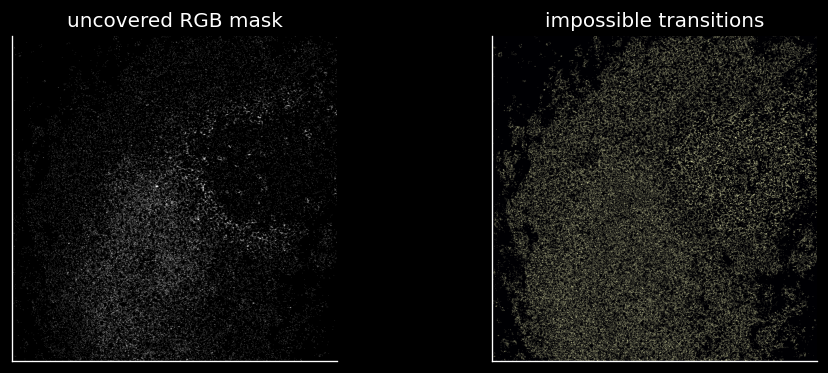

In [15]:
# -----------------------------
# 6. Compact image parsing / transition sanity checks
# -----------------------------
# Run the previous diagnostic cell first so initial_grid, final_grid, raw_final_image,
# and image_to_grid_masks are available.
classified_mask, high_grey_mask = image_to_grid_masks(raw_final_image)
uncovered_mask = ~classified_mask
high_grey_to_zero = high_grey_mask & (final_grid == 0)

print(
    f"uncovered raw-image pixels: {int(uncovered_mask.sum())} / {uncovered_mask.size} "
    f"({uncovered_mask.mean():.2%})"
)
print(
    "high-grey among uncovered pixels: "
    f"{int(high_grey_mask.sum())} = "
    "uncovered & RGB channel range <= 20 & RGB mean >= 80"
)
print(f"high-grey allocated to label 0 pixels: {int(high_grey_to_zero.sum())}")

allowed_changes = {
    (1, 4),
    (1, 5),
    (4, 5),
}
changed = initial_grid != final_grid
from_labels = initial_grid[changed].astype(int)
to_labels = final_grid[changed].astype(int)
from collections import Counter
transition_counts = Counter(zip(from_labels, to_labels))
impossible_counts = {
    pair: count
    for pair, count in transition_counts.items()
    if pair not in allowed_changes
}

print(f"changed pixels: {int(changed.sum())} / {changed.size} ({changed.mean():.2%})")
print("top impossible transitions:")
for (src, dst), count in sorted(impossible_counts.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"  {src} -> {dst}: {count}")


def mask_crop(mask, pad=40):
    ys, xs = np.where(mask)
    if len(ys) == 0:
        return np.s_[0:120, 0:120]
    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, mask.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, mask.shape[1])
    return np.s_[y0:y1, x0:x1]


def scatter_mask(ax, mask, crop=None, color="cyan", size=180, linewidth=2.5):
    view = mask if crop is None else mask[crop]
    ys, xs = np.where(view)
    ax.scatter(xs, ys, s=size, facecolors="none", edgecolors=color, linewidths=linewidth)


highlight_mask = high_grey_to_zero if high_grey_to_zero.any() else high_grey_mask
highlight_title = "high-grey -> label 0" if high_grey_to_zero.any() else "high-grey candidates"
zoom = mask_crop(highlight_mask)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
axes[0].imshow(raw_final_image)
scatter_mask(axes[0], highlight_mask, color="cyan", size=80, linewidth=2.0)
axes[0].set_title(f"full RGB + circles, n={int(highlight_mask.sum())}")

axes[1].imshow(raw_final_image[zoom])
scatter_mask(axes[1], highlight_mask, crop=zoom, color="cyan", size=260, linewidth=3.0)
axes[1].set_title(f"zoom: {highlight_title}")

axes[2].imshow(final_grid[zoom], cmap=state_cmap, vmin=0, vmax=5)
scatter_mask(axes[2], highlight_mask, crop=zoom, color="cyan", size=260, linewidth=3.0)
axes[2].set_title("parsed labels + circles")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

impossible_mask = np.zeros_like(initial_grid, dtype=bool)
for src, dst in impossible_counts:
    impossible_mask |= (initial_grid == src) & (final_grid == dst)
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
axes[0].imshow(uncovered_mask, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("uncovered RGB mask")
axes[1].imshow(impossible_mask, cmap="magma", vmin=0, vmax=1)
axes[1].set_title("impossible transitions")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()
